In [95]:
import warnings
warnings.filterwarnings('ignore')
# step 1: Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
#for sklearn library installation - (pip install scikit-learn) at command prompt
#these are all classes which we import in sklearn library 
from sklearn.model_selection import train_test_split  # break into training and test data
from sklearn.impute import SimpleImputer   #replace the missing values
from sklearn.preprocessing import OneHotEncoder, StandardScaler #for performing encoding and standardscaling
from sklearn.compose import ColumnTransformer  # one col to multiple col --> Categorical value 
from sklearn.base import BaseEstimator, TransformerMixin  #for outliers
from sklearn.decomposition import PCA #for picking up right no. of features
from sklearn.pipeline import Pipeline #for putting all the preprocessing things together we will need pipeline so the data comes one by one piipeline will apply all the concepts  ---keeeping change the data
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # to evaluate regression problem we use metrics mae mse r square
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [97]:
#Load the Dataset 
df=pd.read_csv(r"C:\House Price\House Price Prediction Dataset.csv")
print(df)

        Id  Area in Sqft.  No. of  Bedrooms  No. of Bathrooms  Floors  \
0        1           1360                 5                 4       3   
1        2           4272                 5                 4       3   
2        3           3592                 2                 2       3   
3        4            966                 4                 2       2   
4        5           4926                 1                 4       2   
...    ...            ...               ...               ...     ...   
1995  1996           4994                 5                 4       3   
1996  1997           3046                 5                 2       1   
1997  1998           1062                 5                 1       2   
1998  1999           4062                 3                 1       2   
1999  2000           2989                 5                 1       3   

      YearBuilt  Location  Condition Parking Facility   Price  
0          1970  Downtown  Excellent               No  1499

In [98]:
# First 5 rows of dataset 
df.head()

,Id,Area in Sqft.,No. of Bedrooms,No. of Bathrooms,Floors,YearBuilt,Location,Condition,Parking Facility,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [99]:
# Last 5 rows of dataset
df.tail()


,Id,Area in Sqft.,No. of Bedrooms,No. of Bathrooms,Floors,YearBuilt,Location,Condition,Parking Facility,Price
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119
1999,2000,2989,5,1,3,1903,Suburban,Fair,No,482525


In [100]:
# all columns 
df.columns

Index(['Id', 'Area in Sqft.', 'No. of  Bedrooms', 'No. of Bathrooms', 'Floors',
       'YearBuilt', 'Location', 'Condition', 'Parking Facility', 'Price'],
      dtype='str')

In [101]:
# Shape of dataset
df.shape


(2000, 10)

In [102]:
# Explore the Data
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Id                2000 non-null   int64
 1   Area in Sqft.     2000 non-null   int64
 2   No. of  Bedrooms  2000 non-null   int64
 3   No. of Bathrooms  2000 non-null   int64
 4   Floors            2000 non-null   int64
 5   YearBuilt         2000 non-null   int64
 6   Location          2000 non-null   str  
 7   Condition         2000 non-null   str  
 8   Parking Facility  2000 non-null   str  
 9   Price             2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 184.3 KB


In [103]:
# Separate the categorical and numerical features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['Id', 'Area in Sqft.', 'No. of  Bedrooms', 'No. of Bathrooms', 'Floors', 'YearBuilt', 'Price']
Categorical columns: ['Location', 'Condition', 'Parking Facility']


In [104]:
# Checking Missing Values
df.isnull().sum()


Id                  0
Area in Sqft.       0
No. of  Bedrooms    0
No. of Bathrooms    0
Floors              0
YearBuilt           0
Location            0
Condition           0
Parking Facility    0
Price               0
dtype: int64

In [105]:
# Check Statistics
df.describe()

,Id,Area in Sqft.,No. of Bedrooms,No. of Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [106]:
# Check stats. In table format 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,2000.0,1000.5000,577.494589,1.0,500.75,1000.5,1500.25,2000.0
Area in Sqft.,2000.0,2786.2095,1295.146799,501.0,1653.00,2833.0,3887.50,4999.0
No. of Bedrooms,2000.0,3.0035,1.424606,1.0,2.00,3.0,4.00,5.0
No. of Bathrooms,2000.0,2.5525,1.108990,1.0,2.00,3.0,4.00,4.0
Floors,2000.0,1.9935,0.809188,1.0,1.00,2.0,3.00,3.0
YearBuilt,2000.0,1961.4460,35.926695,1900.0,1930.00,1961.0,1993.00,2023.0
Price,2000.0,537676.8550,276428.845719,50005.0,300098.00,539254.0,780086.00,999656.0


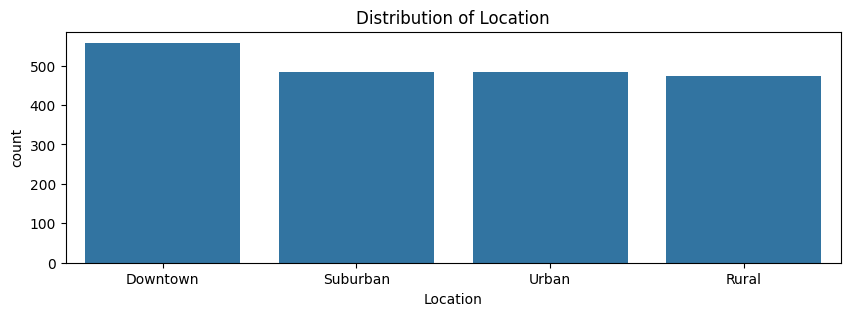

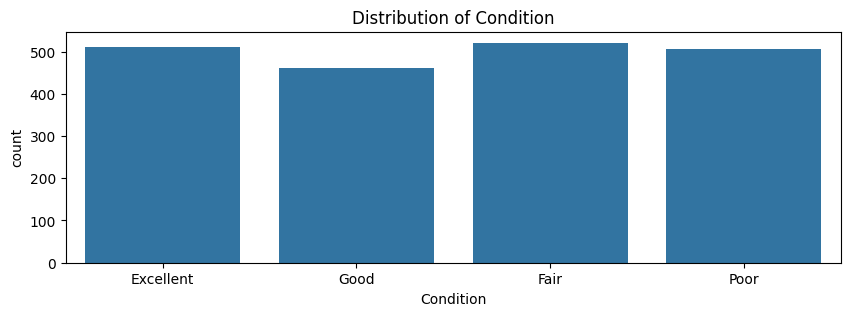

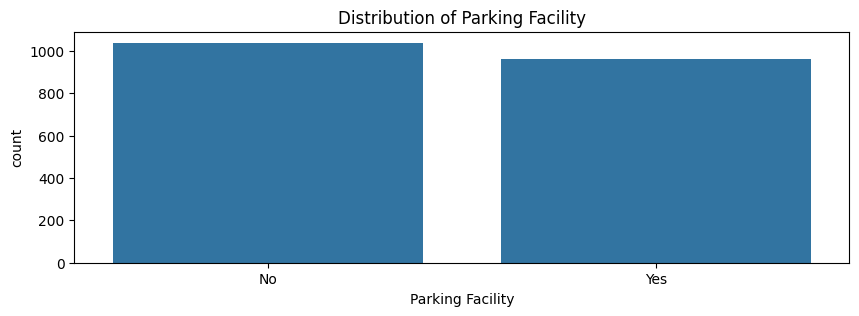

In [107]:
# countplot for categorical columns
for col in cat_cols:
    plt.figure(figsize=(10, 3))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

In [108]:
for col in cat_cols:
    print(df[col].value_counts())

Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64
Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64
Parking Facility
No     1038
Yes     962
Name: count, dtype: int64


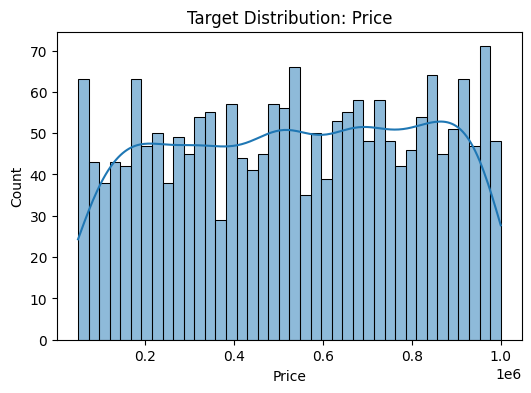

In [109]:
# target column distribution
TARGET_COL = "Price" # target column name
plt.figure(figsize=(6,4))
sns.histplot(df[TARGET_COL], bins=40, kde=True)
plt.title("Target Distribution: Price")
plt.xlabel("Price")
plt.show()

In [110]:
df[TARGET_COL].value_counts()

Price
959222    2
149919    1
424998    1
266746    1
244020    1
         ..
295620    1
580929    1
476925    1
161119    1
482525    1
Name: count, Length: 1999, dtype: int64

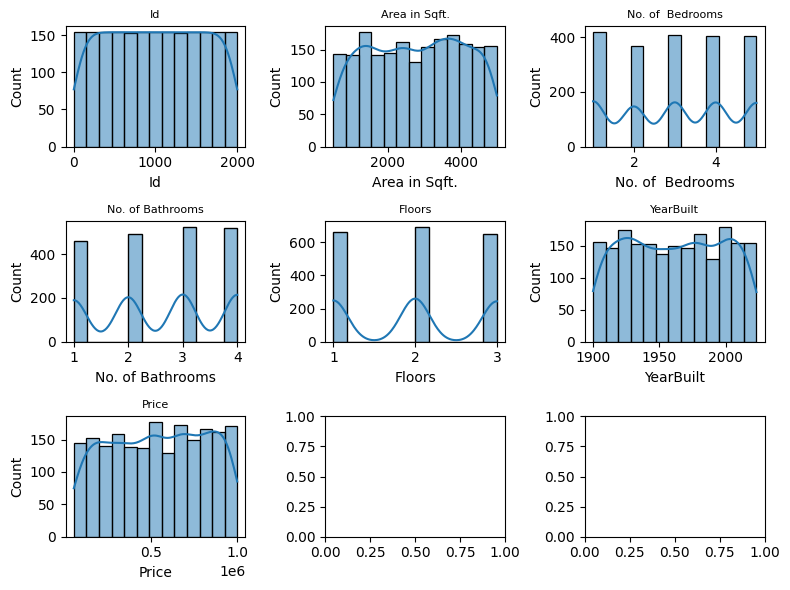

In [111]:
# histogram plot - distribution
fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

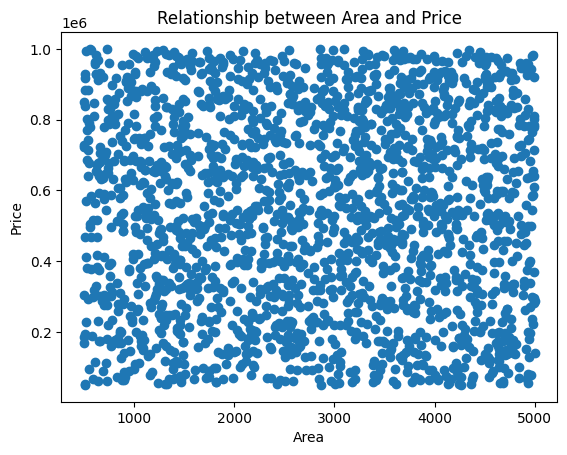

In [112]:
# Visualize  the Data 
plt.title("Relationship between Area and Price")
plt.scatter(df["Area in Sqft."],df["Price"])
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()



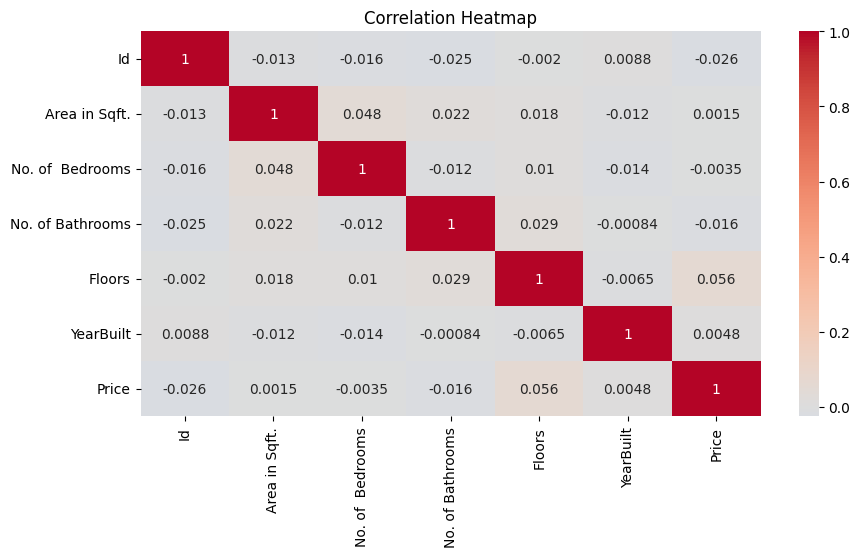

In [113]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(10, 5))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

In [114]:
# Data preprocessing Separate Features and Targets
#Define Input X and Output y
X=df[["Area in Sqft.","No. of  Bedrooms","No. of Bathrooms","Floors","YearBuilt"]]
y=df["Price"]
print(y)


0       149919
1       424998
2       266746
3       244020
4       636056
         ...  
1995    295620
1996    580929
1997    476925
1998    161119
1999    482525
Name: Price, Length: 2000, dtype: int64


In [115]:
print(X)

      Area in Sqft.  No. of  Bedrooms  No. of Bathrooms  Floors  YearBuilt
0              1360                 5                 4       3       1970
1              4272                 5                 4       3       1958
2              3592                 2                 2       3       1938
3               966                 4                 2       2       1902
4              4926                 1                 4       2       1975
...             ...               ...               ...     ...        ...
1995           4994                 5                 4       3       1923
1996           3046                 5                 2       1       2019
1997           1062                 5                 1       2       1903
1998           4062                 3                 1       2       1936
1999           2989                 5                 1       3       1903

[2000 rows x 5 columns]


In [116]:
# Split Data into training and testing 
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [117]:
X_train


,Area in Sqft.,No. of Bedrooms,No. of Bathrooms,Floors,YearBuilt
968,4483,4,4,3,1933
240,1062,3,3,1,1970
819,1422,3,4,1,1993
692,2658,2,3,1,1972
420,3286,2,4,1,1981
...,...,...,...,...,...
1130,3483,5,3,3,1931
1294,1747,3,3,2,1941
860,1484,2,3,3,1973
1459,3456,5,4,1,1955


In [118]:
X_test

,Area in Sqft.,No. of Bedrooms,No. of Bathrooms,Floors,YearBuilt
1860,633,1,4,2,1901
353,3856,1,1,2,1901
1333,1598,5,4,1,2013
905,1705,3,1,2,1996
1289,2564,5,2,3,1994
...,...,...,...,...,...
965,1811,1,3,3,1970
1284,794,3,2,2,2013
1739,3540,4,4,2,1939
261,3670,5,2,2,1910


In [119]:
y_train

968     434325
240     614772
819     922811
692     794314
420     796988
         ...  
1130    387088
1294    942215
860     323139
1459    274997
1126    644206
Name: Price, Length: 1600, dtype: int64

In [120]:
y_test

1860    514764
353     694256
1333     66375
905     650243
1289    223285
         ...  
965     386940
1284    632570
1739    494049
261     562193
535     447530
Name: Price, Length: 400, dtype: int64

In [121]:
#Train the AI Model by using Linear Regression
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [122]:
score=model.score(X_test,y_test)
print("\n Model Performance:",round(score * 100,2),"%")


 Model Performance: -1.27 %


In [123]:
# Make Predictions
y_pred = model.predict(X_test)
print(y_pred[:10])


[515577.20094333 544286.23995207 504412.67222196 555773.69096497
 568830.77263034 550559.76495508 551103.35655728 545058.55449332
 563718.90528357 569110.12168438]


In [124]:
# Make Predictions
predictions = model.predict(X_test)
print(predictions[:5])


#The model now predicts house prices for unseen houses.


[515577.20094333 544286.23995207 504412.67222196 555773.69096497
 568830.77263034]


In [133]:
# Actual and Predicted Y
import pandas as pd

compare_df = pd.DataFrame({
    'Actual Y': y_test,
    'Predicted Y': y_pred
})

print(compare_df)



      Actual Y    Predicted Y
1860    514764  515577.200943
353     694256  544286.239952
1333     66375  504412.672222
905     650243  555773.690965
1289    223285  568830.772630
...        ...            ...
965     386940  556358.712145
1284    632570  548055.892093
1739    494049  518877.978887
261     562193  535501.877261
535     447530  572150.738293

[400 rows x 2 columns]


In [139]:
#Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
model= RandomForestRegressor(n_estimators=200,random_state=42)
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [140]:
# Calculate Mean Squared Error
y_pred= model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)
print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 85956489728.61536


In [86]:
#Calculate R2 Score
from sklearn.metrics import r2_score
predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)   # store result in r2
print("R² Score:", r2)


R² Score: -0.01273663755401877


In [87]:
# Calculate Mean Absolute Error
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions) 
print("MAE:", mean_absolute_error(y_test,predictions))

MAE: 244587.1999197856


In [ ]:
# Example
# Area in Sqft.=1965
#No. of  Bedrooms = 4	
#No. of Bathrooms = 4	
# Floors	= 18
#YearBuilt  = 2018


In [88]:
# Price prediction of a New House
new_house = [[1965,4,4,18,2018]]
predicted_price = model.predict(new_house)
print("\n Predicted House Price:")
print ("Rs.", round(predicted_price[0],2), "Lakh")


 Predicted House Price:
Rs. 904249.65 Lakh


In [143]:
sample = X.iloc[[0]]   
predicted_price = model.predict(sample)

print(f"Predicted Price: {predicted_price[0]:,.2f}")


Predicted Price: 346,722.92
